In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import glob
import os
import numpy as np
import itertools
import ast
import datetime
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import griddata
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import iris

import iris.quickplot as qplt
import iris.plot as iplt
degree_sign= u'\N{DEGREE SIGN}'
import cmocean
import xarray as xr

def format_x_and_y_ticks(ax: plt.axes, xlocs: list, ylocs: list):
    """Format geoaxes ticks.

    Args:
        ax (plt.axes): axes
        xlocs (list): x locations
        ylocs (list): y locations

    Returns:
        ax: axes
    """

    # Make nicely formatted x- and y-ticks
    xlabels = []
    for j in range(len(xlocs)):
        if xlocs[j] > 0 :
            xlabels.append(f"{abs(xlocs[j]):.1f}{degree_sign}E")
        elif xlocs[j] == 0:
            xlabels.append(f"{abs(xlocs[j]):.0f}{degree_sign}")
        else:
            xlabels.append(f"{abs(xlocs[j]):.1f}{degree_sign}W")
            
    ax.set_xticks(xlocs)
    ax.set_xticklabels(xlabels)

    ylabels = []
    for j in range(len(ylocs)):
        if ylocs[j] < 0 :
            ylabels.append(f"{abs(ylocs[j]):.1f}{degree_sign}S")
        elif ylocs[j] == 0:
            ylabels.append(f"{abs(ylocs[j]):.0f}{degree_sign}")
        else:
            ylabels.append(f"{ylocs[j]:.1f}{degree_sign}N")
    ax.set_yticks(ylocs)
    ax.set_yticklabels(ylabels)
    ax.grid(linewidth=0.3)
    ax.set_xlabel("")
    ax.set_ylabel("")

    return ax

def circ_mean(h):
    return (np.arctan2(np.sin(2*np.pi*h/24).mean(),np.cos(2*np.pi*h/24).mean()) * 24/(2*np.pi)) % 24

In [10]:
models = ["n1280_CoMA9", "n1280_GAL9_v2", "n2560_CoMA9_hier_v2", "n2560_RAL3p3_tuned"]

In [11]:
def load_mcs(model_id):
    files = glob.glob(f"/gws/ssde/j25a/ncas_climate/vol1/users/ekarl20/data/hackathon_monsoon_data/{model_id}/*.csv")
    
    dfs = []
    
    for file in files:
        dfs.append(pd.read_csv(file))
    
    df = pd.concat(dfs)
    df["timestamp"] = pd.to_datetime(df.timestamp)
    df["model_id"] = model_id

    return df

dfs = []

for model_id in models:
    dfs.append(load_mcs(model_id))

df = pd.concat(dfs)

In [28]:
def find_regions(region):

    regions = { "West Africa": {"lat_min": 0, "lat_max": 25, "lon_min": -25, "lon_max": 20}, 
        "South Asia": {"lat_min": 0, "lat_max": 35, "lon_min": 50, "lon_max": 110},
        "East Asia": {"lat_min": 15, "lat_max": 50, "lon_min": 95, "lon_max": 150},
        "North America": {"lat_min": 0, "lat_max": 35, "lon_min": -120, "lon_max": -60},
        "Southern Africa": {"lat_min": -35, "lat_max": -5, "lon_min": 5, "lon_max": 50},
        "Maritime Continent": {"lat_min": -30, "lat_max": 20, "lon_min": 100, "lon_max": 160},
        "South America": {"lat_min": -35, "lat_max": 10, "lon_min": -90, "lon_max": -30}}
    
    return regions[region]
        
regions_list = ["West Africa", "South Asia", "East Asia", "North America", "Southern Africa", "Maritime Continent", "South America"]

In [29]:
df["pr_meanxarea"] = df.pr_mean*df.area

In [30]:
mcs_count = np.zeros((len(models), len(regions_list), 12))
rainfall = np.zeros((len(models), len(regions_list), 12))

for mdx, model_id in enumerate(models):
    df_ = df[df.model_id == model_id]
    df_storm = df_.groupby("storm_id").first()
    for rdx, region in enumerate(regions_list):
        region_bounds = find_regions(region)
        lat1, lat2, lon1, lon2 = region_bounds["lat_min"], region_bounds["lat_max"], region_bounds["lon_min"],  region_bounds["lon_max"]
        # print(lat1, lat2, lon1, lon2)
        df2 = df_storm[(df_storm.lon >= lon1) & (df_storm.lon <= lon2) & (df_storm.lat >= lat1) & (df_storm.lat <= lat2)]
        #print(df_storm)
        # print(region, len(df2))
        mcs_count[mdx, rdx] = df2.groupby(df2.timestamp.dt.month).size().reindex(range(1,13), fill_value=0)
        rainfall[mdx, rdx] = (df2.groupby(df2.timestamp.dt.month).pr_meanxarea.sum()).reindex(range(1,13), fill_value=0)

In [31]:
colour_dict = {"n2560_CoMA9_hier_v2": "royalblue",
               "n2560_RAL3p3_tuned": "forestgreen",
              "n1280_CoMA9": "magenta",
               "n1280_GAL9_v2": "gold"
              }

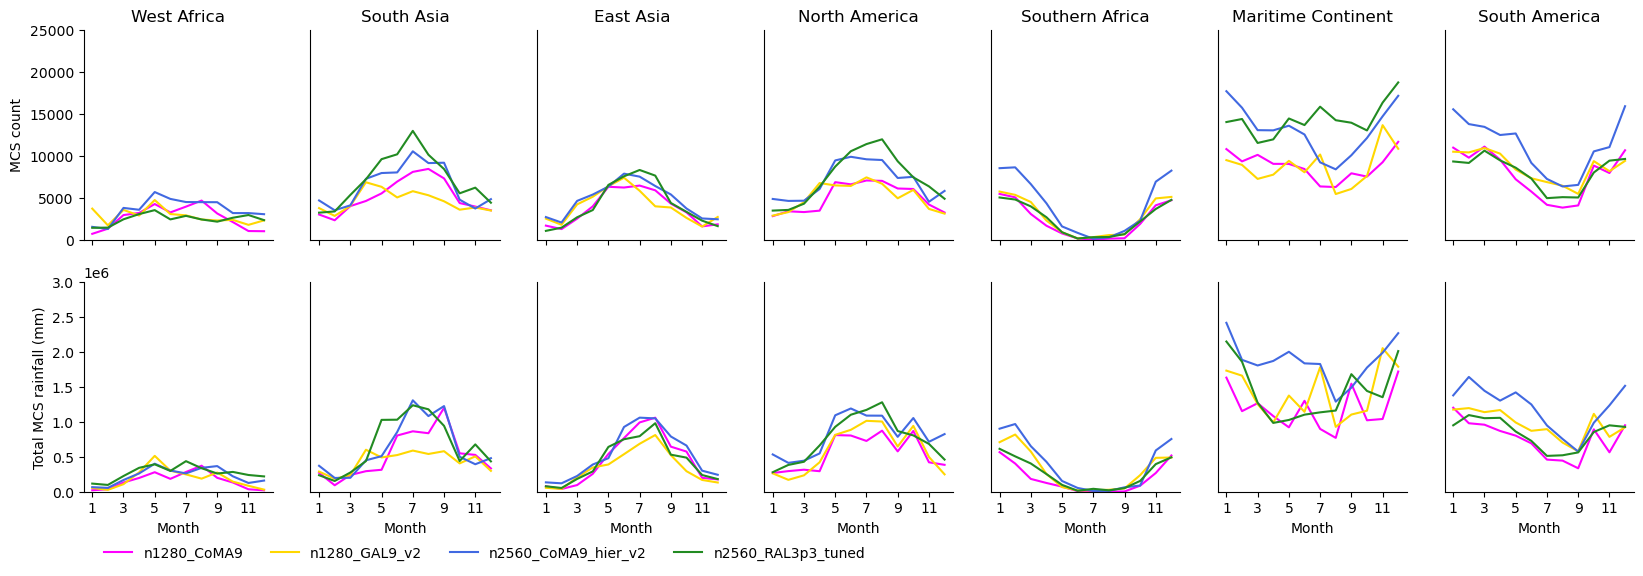

In [34]:
fig, axes = plt.subplots(2,len(regions_list), figsize=(20,6), sharex=True)

for mdx, model_id in enumerate(models):
    for rdx, region in enumerate(regions_list):
        axes[0,rdx].plot(range(1,13), mcs_count[mdx,rdx], color=colour_dict[model_id], label=model_id)
        axes[0,rdx].set_title(regions_list[rdx])
        axes[1,rdx].set_xlabel("Month")
        axes[0,rdx].set_xticks(range(1,13, 2))
        axes[0,rdx].set_ylim(0,25000)

        axes[1,rdx].plot(range(1,13), rainfall[mdx,rdx], color=colour_dict[model_id], label=model_id)
        axes[1,rdx].set_ylim(0,3e6)

        if rdx > 0:
            axes[0,rdx].axes.get_yaxis().set_ticks([])
            axes[1,rdx].axes.get_yaxis().set_ticks([])

for ax in axes.ravel():
    ax.spines[['right', 'top']].set_visible(False)
        
axes[0,0].set_ylabel("MCS count")
axes[1,0].set_ylabel("Total MCS rainfall (mm)")

axes[1,0].legend(frameon=False, ncols=4, bbox_to_anchor=(4.2,-0.2))
        
plt.show()

In [35]:
seasons = {"OND": [10,11,12],
          "JJAS": [6,7,8,9],
          "JF": [1,2],
          "MAM": [3,4,5]}

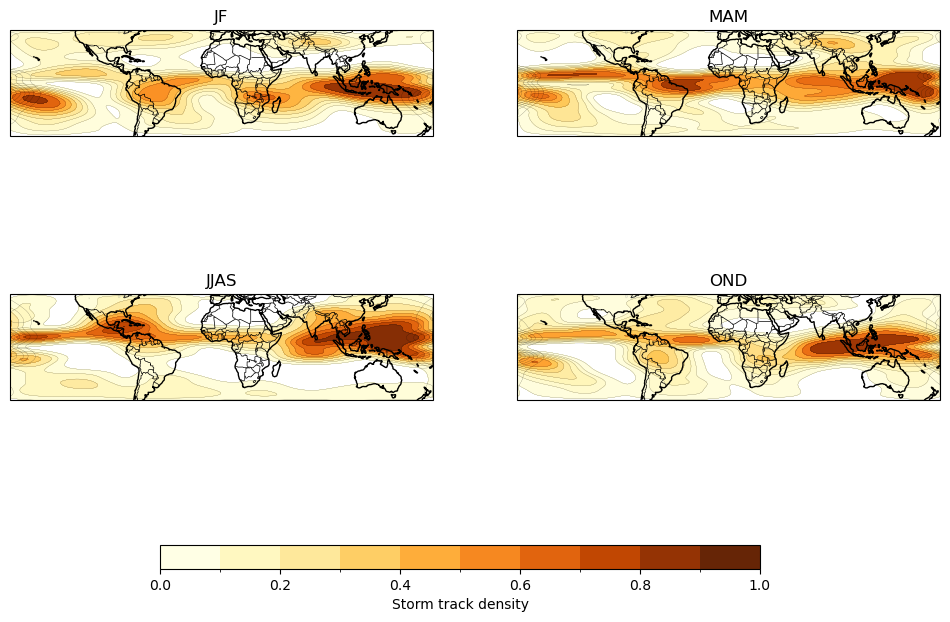

In [30]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

extent = [30.0, 35.5, -3.5, 1.5]
xlocs = [31.5, 33, 34.5]
ylocs = [-3,-1.5,0,1.5]

figsize=(6*2,6*2)

fig, axes = plt.subplots(2,2, figsize=figsize,subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=0)), facecolor="white")


cmap=plt.get_cmap("twilight")
bounds=np.arange(0,25,1)

norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

# df_obs2 = df_obs.groupby("Storm").first()
# df2 = df.groupby("storm_id").first()

season_list = ["JF", "MAM", "JJAS", "OND"]

for i, ax in enumerate(axes.ravel()):
    season = season_list[i]
    ax.coastlines(resolution="110m")
    ax.set_extent([-180,180,-45,45])
    
    ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidths=0.5)
    ax.add_feature(cfeature.LAKES, edgecolor="black", linewidths=0.5, alpha=0.1)
    
    df2 = df.groupby("storm_id").first()
    df2 = df2[df2.timestamp.dt.month.isin(seasons[season])]
    
    kde1 = sns.kdeplot(x=df2.lon,  y=df2.lat, ax=ax, fill=True, cmap="YlOrBr", alpha=1)
    
    kde = sns.kdeplot(x=df2.lon,  y=df2.lat, ax=ax, fill=False, color="black",
                        linewidths=0.1)
    ax.set_title(season)
    
    
    # sc = ax.scatter(df2.lon, df2.lat, c=df2.eat_hours, cmap=cmap, norm=norm, s=10, transform=ccrs.PlateCarree())
    
    # ax.set_title(extents[storm_type]['label'], color=extents[storm_type]['color'])
    
    ax.set_xlabel("")
    ax.set_ylabel("")


cmap = mpl.cm.YlOrBr
bounds = np.arange(0.,1.01,0.1)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

cbar_ax = fig.add_axes([0.25, 0.20, 0.5, 0.02])   # [left, bottom, width, height]

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
cbar.set_label("Storm track density")

plt.subplots_adjust(hspace=-0.6)

plt.show()

# East Africa

In [17]:
def subset_domain(lat1: float, lat2: float, lon1: float, lon2: float, df: pd.DataFrame, storm_label="Storm"):
    """Subset dataframe of storm track with storms that at any
    point cross the box with given latitude and longitude bounds

    Args:
        lat1 (float): minimum latitude
        lat2 (float): maximum latitude
        lon1 (float): minimum longitude
        lon2 (float): maximum longitude
        df (pd.DataFrame): dataframe to subset
        storm_label (str, optional): storm identifier column. Defaults to "Storm".

    Returns:
        _type_: _description_
    """
   
    df["LonInBounds"] = (df.lon <= lon2) & (df.lon >= lon1)
    df["LatInBounds"]= (df.lat <= lat2) & (df.lat >= lat1)
    df["in_domain"] = df["LonInBounds"] & df["LatInBounds"]
    
    # Find any points within each storm that cross domain
    storms_in_domain = df.groupby(storm_label).size()[df.groupby(storm_label).in_domain.any()]
    storms_in_domain = storms_in_domain.index
    
    df = df[df[storm_label].isin(storms_in_domain)]

    return df

In [65]:
dfs = []
fnames = glob.glob("../../storms_hill_etal*.csv")

for fname in fnames:
    dfs.append(pd.read_csv(fname))

df_obs_gah = pd.concat(dfs)
df_obs_gah["Initial UTC"] = pd.to_datetime(df_obs_gah["Initial UTC"])
df_obs_gah["Final UTC"] = pd.to_datetime(df_obs_gah["Final UTC"])

df_obs_gah["duration"] = df_obs_gah["Final UTC"] - df_obs_gah["Initial UTC"]
df_obs_gah["duration_hr"] = df_obs_gah["duration"].dt.total_seconds()/3600.0
df_obs_gah = df_obs_gah[df_obs_gah.duration_hr >= 1]

In [38]:
lat1, lat2, lon1, lon2 = -10, 12, 30, 52

df_gah = subset_domain(lat1, lat2, lon1, lon2, df, storm_label="storm_id")

In [74]:
resolution = {"n1280_CoMA9": 10, 
              "n1280_GAL9_v2": 10, 
              "n2560_CoMA9_hier_v2": 5,
              "n2560_RAL3p3_tuned": 5}

In [80]:
model = models[i]

df_gah[df_gah.model_id == model].area*resolution[model]*resolution[model] <= 1000

16         True
17        False
18        False
19        False
20        False
          ...  
233075     True
233091    False
233092    False
233093    False
233094    False
Name: area, Length: 211003, dtype: bool

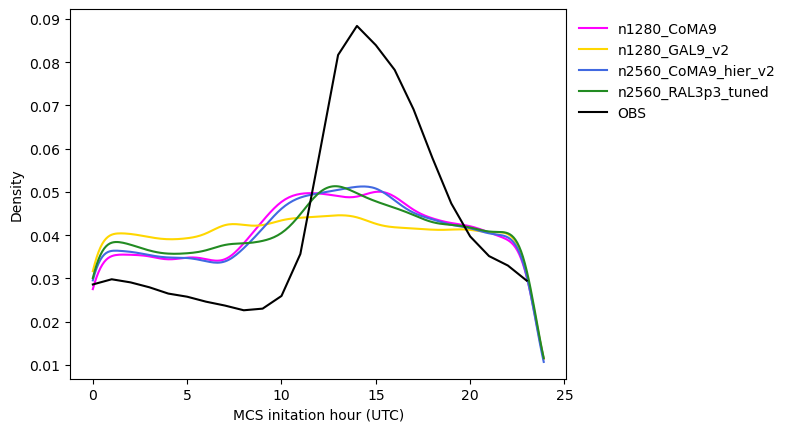

In [69]:
from scipy.stats import gaussian_kde

for model in models:

    kde = gaussian_kde(df_gah[df_gah.model_id == model].groupby(["storm_id"]).first().timestamp.dt.hour)
    bins = np.arange(0,24,0.1)
    plt.plot(bins,kde(bins),color=colour_dict[model], label=model)

bins = np.arange(0,24,1)
df2_ = df_obs_gah.groupby("Storm").first()
kde = gaussian_kde((df2_["Initial UTC"]+datetime.timedelta(hours=3)).dt.hour)
plt.plot(bins, kde(bins), label="OBS", color="black")

plt.legend(frameon=False, ncols=1, bbox_to_anchor=(1,1))

plt.xlabel("MCS initation hour (UTC)")
plt.ylabel("Density")

plt.show()

In [ ]:
from scipy.stats import gaussian_kde

bins = np.arange(0, 25, 1)

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

figsize=(6*2,5)
    

season_list = ["JF", "MAM", "JJAS", "OND"]

fig, axes = plt.subplots(2,4, figsize=figsize,facecolor="white", sharex=True, sharey=True)

fcast_day = 1

for idx, ax in enumerate(axes[0]):

    season = season_list[idx]

    df2_ = (df[(df.fcast_day == fcast_day) & (df.fcast_init.dt.month.isin(seasons[season]))].groupby("storm_id").first())
    kde = gaussian_kde((df2_["Initial_UTC"]+datetime.timedelta(hours=3)).dt.hour)

    ax.plot(bins, kde(bins), color="royalblue", label="MetUM global 5km")

    df2_ = (df_obs_gah[(df_obs_gah["Initial UTC"].dt.month.isin(seasons[season])) & (df_obs_gah.duration_hr >= 1.0)].groupby("Storm").first())
    kde = gaussian_kde((df2_["Initial UTC"]+datetime.timedelta(hours=3)).dt.hour)
    ax.plot(bins, kde(bins), label="OBS", color="black")

    ax.text(0.04, 0.96, f"{season}", fontsize=9,
                    bbox=dict(facecolor='blanchedalmond', edgecolor='black', 
                    linewidth=0.1, pad=0.2, alpha=1, boxstyle='round'), horizontalalignment="left", 
                    verticalalignment="top", zorder=200, transform=ax.transAxes)

ax.set_title(f"Lead day = {fcast_day}", loc="right")
    
fcast_day = 15

for idx, ax in enumerate(axes[1]):

    season = season_list[idx]

    df2_ = (df[(df.fcast_day == fcast_day) & (df.fcast_init.dt.month.isin(seasons[season]))].groupby("storm_id").first())
    kde = gaussian_kde((df2_["Initial_UTC"]+datetime.timedelta(hours=3)).dt.hour)

    ax.plot(bins, kde(bins), color="royalblue", label="MetUM global 5km")

    df2_ = (df_obs_gah[(df_obs_gah["Initial UTC"].dt.month.isin(seasons[season])) & (df_obs_gah.duration_hr >= 1.0)].groupby("Storm").first())
    kde = gaussian_kde((df2_["Initial UTC"]+datetime.timedelta(hours=3)).dt.hour)
    ax.plot(bins, kde(bins), label="OBS", color="black")

    #ax.set_title(season, loc="left")

    ax.text(0.04, 0.96, f"{season}", fontsize=9,
                    bbox=dict(facecolor='blanchedalmond', edgecolor='black', 
                    linewidth=0.1, pad=0.2, alpha=1, boxstyle='round'), horizontalalignment="left", 
                    verticalalignment="top", zorder=200, transform=ax.transAxes)


ax.set_title(f"Lead day = {fcast_day}", loc="right")

plt.legend(loc="best", fontsize=6)

ax.set_xticks([0,6,12,18,24])


for ax in axes[-1]:
    ax.set_xlabel("MCS initiation hour\n(East Africa Time, UTC + 3 hr)")

for ax in axes[:,0]:
    ax.set_ylabel("Density")

plt.show()

KeyboardInterrupt: 

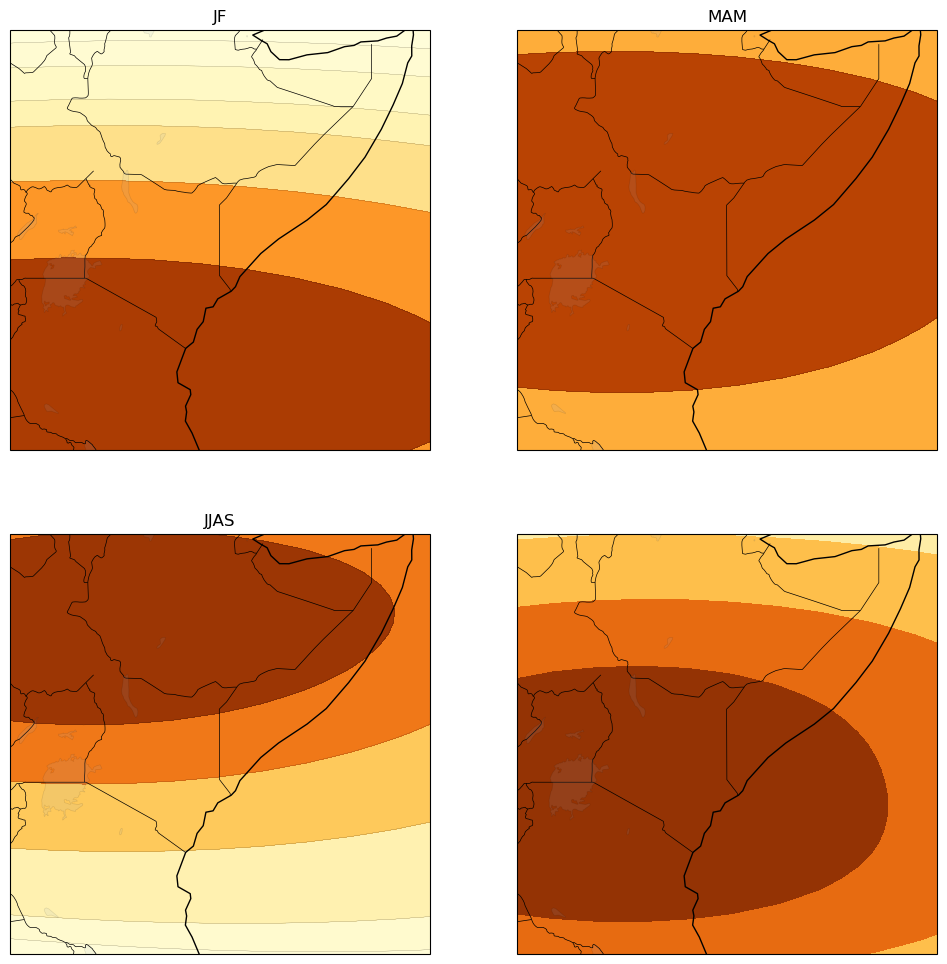

In [43]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

extent = [30.0, 35.5, -3.5, 1.5]
xlocs = [31.5, 33, 34.5]
ylocs = [-3,-1.5,0,1.5]

figsize=(6*2,6*2)

for model in models:

    fig, axes = plt.subplots(2,2, figsize=figsize,subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=0)), facecolor="white")
    
    cmap=plt.get_cmap("twilight")
    bounds=np.arange(0,25,1)
    
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    # df_obs2 = df_obs.groupby("Storm").first()
    # df2 = df.groupby("storm_id").first()
    
    season_list = ["JF", "MAM", "JJAS", "OND"]
    
    for i, ax in enumerate(axes.ravel()):
        season = season_list[i]
        ax.coastlines(resolution="110m")
        ax.set_extent([lon1,lon2,lat1,lat2])
        
        ax.add_feature(cfeature.BORDERS, edgecolor="black", linewidths=0.5)
        ax.add_feature(cfeature.LAKES, edgecolor="black", linewidths=0.5, alpha=0.1)
        
        df2 = df_gah[df_gah.model_id==model].groupby("storm_id").first()
        df2 = df2[df2.timestamp.dt.month.isin(seasons[season])]
        
        kde1 = sns.kdeplot(x=df2.lon,  y=df2.lat, ax=ax, fill=True, cmap="YlOrBr", alpha=1)
        
        kde = sns.kdeplot(x=df2.lon,  y=df2.lat, ax=ax, fill=False, color="black",
                            linewidths=0.1)
        ax.set_title(season)
        
        
        # sc = ax.scatter(df2.lon, df2.lat, c=df2.eat_hours, cmap=cmap, norm=norm, s=10, transform=ccrs.PlateCarree())
        
        # ax.set_title(extents[storm_type]['label'], color=extents[storm_type]['color'])
        
        ax.set_xlabel("")
        ax.set_ylabel("")
    
    
    cmap = mpl.cm.YlOrBr
    bounds = np.arange(0.,1.01,0.1)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    cbar_ax = fig.add_axes([0.25, 0.20, 0.5, 0.02])   # [left, bottom, width, height]
    
    cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Storm track density")
    
    #plt.subplots_adjust(hspace=-0.6)
    plt.suptitle(model)
    
    plt.show()